# 鸢尾花分类工作

## 1.数据加载与预处理
### 使用sklearn.datasets.load_iris()加载鸢尾花数据集
### 加载数据后，将数据转化为Pandas DataFrame以便查看和操作

### 1️⃣load_iris() 加载数据集，返回一个包含特征 (data)、标签 (target) 及描述信息的字典。
### 2️⃣pd.DataFrame(iris.data, columns=iris.feature_names) 将数据转换为 DataFrame。
### 3️⃣df['species'] = iris.target 添加目标列，类别为 0、1、2，分别表示三种鸢尾花类别。

In [1]:
# 导入必要的库
from sklearn.datasets import load_iris
import pandas as pd

# 加载鸢尾花数据集
iris = load_iris()

# 创建 DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# 添加目标列（类别）
df['species'] = iris.target

# 查看前 5 行数据
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


## 2.数据可视化
### 通过Matploblib和Seaborn绘制图表
### 算法：plt.plot(), sbs.pairplot(), sbs.boxplot()等
### 操作：绘制散点图、箱型图、特征之间的关系
### 1️⃣散点图矩阵 (sns.pairplot())：显示所有特征之间的关系，并用 hue="species" 颜色区分三种类别。
### 2️⃣箱型图 (sns.boxplot())：显示某个特征（例如 sepal length）在不同类别中的分布情况，帮助发现类别间的显著差异。

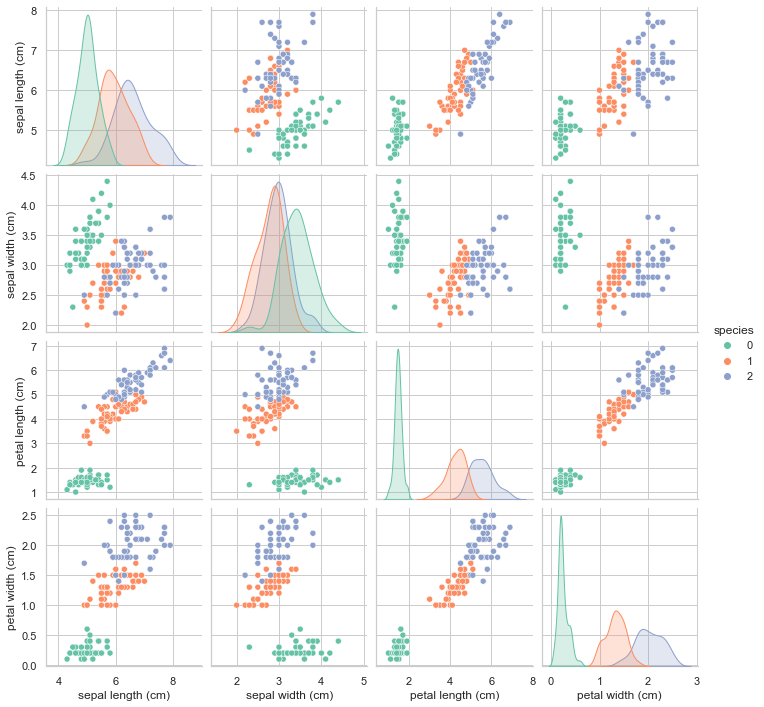

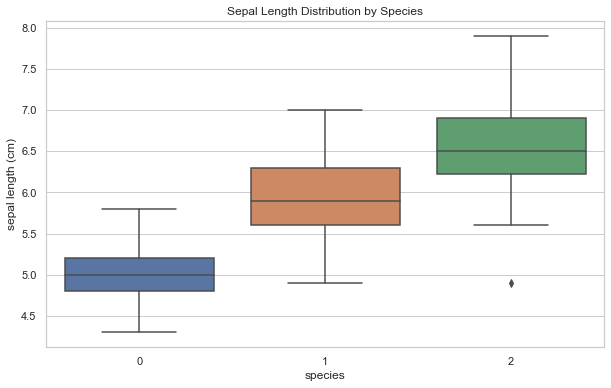

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置 Seaborn 风格
sns.set(style="whitegrid")

# 1. 绘制特征之间的关系散点图
sns.pairplot(df, hue="species", palette="Set2")# Set1、coolwarm、husl、pastel
plt.show()

# 2. 绘制箱型图，观察不同类别的分布
plt.figure(figsize=(10,6))
sns.boxplot(x='species', y='sepal length (cm)', data=df)
plt.title("Sepal Length Distribution by Species")
plt.show()

## 3.使用scikit-learn构建分类模型（如KNN或逻辑回归）
### 模型构建：选择K-近邻（KNN）或逻辑回归（Logistic Regression）算法
### 算法：KNeighborsClassifier()或LogisticRegression()
### 操作：划分训练集和测试集，选择模型进行训练
### 1️⃣train_test_split() 将数据集拆分为训练集（70%）和测试集（30%）。
### 2️⃣KNeighborsClassifier(n_neighbors=3) 使用 KNN 进行分类，这里 K 取 3。
### 3️⃣LogisticRegression(max_iter=200) 训练逻辑回归模型，max_iter=200 确保收敛。

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# 划分训练集和测试集（70% 训练集，30% 测试集）
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df['species'], test_size=0.3, random_state=42)
# 42 是一个 经典的随机种子数，来源于科幻小说《银河系漫游指南》，其中 “生命、宇宙以及一切的终极答案” 是 42，因此被许多程序员用于随机种子

# 训练 KNN 分类模型
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# 训练逻辑回归模型
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [21]:
# for i in [100, 200, 500, 1000]:
#     logreg = LogisticRegression(max_iter=i)
#     logreg.fit(X_train, y_train)
#     print(f"max_iter={i}, Score: {logreg.score(X_test, y_test)}")

'for i in [100, 200, 500, 1000]:\n    logreg = LogisticRegression(max_iter=i)\n    logreg.fit(X_train, y_train)\n    print(f"max_iter={i}, Score: {logreg.score(X_test, y_test)}")'

## 4.评估模型性能（使用准确度、混淆矩阵等）
### 性能评估：使用准确度、混淆矩阵和分类报告评估模型
### 算法：accuracy_score(), confusion_matrix(), classification_report()
### 操作：输出模型的准确度、混淆矩阵以及分类报告。
### 1️⃣accuracy_score() 计算分类准确率。
### 2️⃣confusion_matrix() 生成混淆矩阵，显示分类错误的情况。
### 3️⃣classification_report() 输出精确率、召回率和 F1 分数，全面评估模型性能。

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# KNN 模型评估
y_pred_knn = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn}")

# 逻辑回归模型评估
y_pred_logreg = logreg.predict(X_test)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Accuracy: {accuracy_logreg}")

# 输出混淆矩阵
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

print("KNN Confusion Matrix:")
print(cm_knn)

print("Logistic Regression Confusion Matrix:")
print(cm_logreg)

# 输出分类报告
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg))

KNN Accuracy: 1.0
Logistic Regression Accuracy: 1.0
KNN Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Logistic Regression Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00    

## 5.对新数据进行预测
### 新数据预测：选择模型进行新数据预测
### 算法：使用训练好的模型（KNN或逻辑回归）进行预测
### 操作：输入一个新的样本数据点，输出预测结果
### 1️⃣knn.predict() 和 logreg.predict() 对新数据进行分类。
### 2️⃣结果会返回一个类别（0、1 或 2），对应鸢尾花的三种类型。

In [6]:
# 定义新的样本数据
new_sample = [[5.1, 3.5, 1.4, 0.2]]

# 预测新数据类别
prediction_knn = knn.predict(new_sample)
prediction_logreg = logreg.predict(new_sample)

print(f"KNN Predicted class: {prediction_knn}")
print(f"Logistic Regression Predicted class: {prediction_logreg}")

KNN Predicted class: [0]
Logistic Regression Predicted class: [0]


/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
